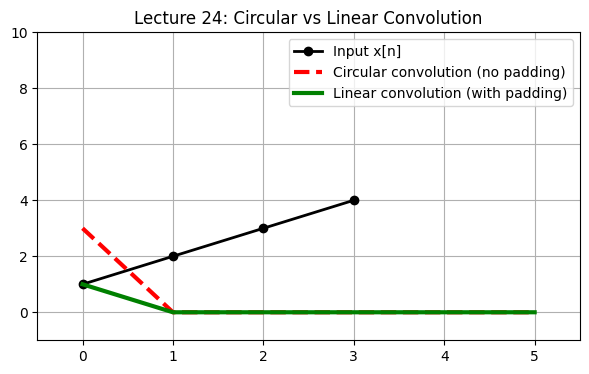

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# -----------------------------
# Lecture 24: Circular vs Linear Convolution
# -----------------------------

# Input signal
x = np.array([1, 2, 3, 4])
h = np.array([1, -1, 2])

# Linear convolution (correct result)
y_linear = np.convolve(x, h)

# Circular convolution (no zero-padding)
N = max(len(x), len(h))
y_circular = np.fft.ifft(
    np.fft.fft(x, N) * np.fft.fft(h, N)
).real

n = np.arange(len(y_linear))

# Plot setup
fig, ax = plt.subplots(figsize=(7, 4))
ax.set_xlim(-0.5, len(y_linear) - 0.5)
ax.set_ylim(min(y_linear) - 2, max(y_linear) + 2)
ax.grid(True)
ax.set_title("Lecture 24: Circular vs Linear Convolution")

# Static input (for reference)
ax.plot(np.arange(len(x)), x, 'k-o', lw=2, label="Input x[n]")

# Animated outputs
circ_line, = ax.plot([], [], 'r--', lw=3,
                     label="Circular convolution (no padding)")
lin_line,  = ax.plot([], [], 'g', lw=3,
                     label="Linear convolution (with padding)")

ax.legend(loc="upper right")

# -----------------------------
# Animation update (Lecture‑9 style)
# -----------------------------
def update(frame):
    circ_disp = np.zeros_like(y_linear)
    lin_disp = np.zeros_like(y_linear)

    # circular result wraps and truncates
    circ_disp[:min(frame+1, len(y_circular))] = y_circular[:frame+1]

    # linear result grows correctly
    lin_disp[:frame+1] = y_linear[:frame+1]

    circ_line.set_data(n, circ_disp)
    lin_line.set_data(n, lin_disp)

    return circ_line, lin_line

anim = FuncAnimation(
    fig,
    update,
    frames=len(y_linear),
    interval=800
)

HTML(anim.to_jshtml())


✅ Green curve (linear) builds correctly
❌ Red curve (circular) wraps early values to the beginning
The error becomes visually obvious near the end

This shows why FFT convolution fails without zero‑padding.